In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("patient_data.csv")
print(df.shape)        # rows, columns
df.head()

(101766, 25)


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,gender,race,...,max_glu_serum,diabetesMed,change,insulin,metformin,glipizide,glyburide,pioglitazone,rosiglitazone,readmitted
0,1,41,0,1,0,0,0,1,Female,Caucasian,...,NaN,No,No,No,No,No,No,No,No,NO
1,3,59,0,18,0,0,0,9,Female,Caucasian,...,NaN,Yes,Ch,Up,No,No,No,No,No,>30
2,2,11,5,13,2,0,1,6,Female,AfricanAmerican,...,NaN,Yes,No,No,No,Steady,No,No,No,NO
3,2,44,1,16,0,0,0,7,Male,Caucasian,...,NaN,Yes,Ch,Up,No,No,No,No,No,NO
4,1,51,0,8,0,0,0,5,Male,Caucasian,...,NaN,Yes,Ch,Steady,No,Steady,No,No,No,NO


In [18]:
df.describe()  

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,admission_type_id,discharge_disposition_id,admission_source_id
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607,2.024006,3.715642,5.754437
std,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600,1.445403,5.280166,4.064081
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000,1.000000,1.000000,1.000000
50%,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000,1.000000,1.000000,7.000000
75%,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000,3.000000,4.000000,7.000000
max,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000,8.000000,28.000000,25.000000


In [19]:
df.isnull().sum().sort_values(ascending=False)

max_glu_serum               96420
A1Cresult                   84748
race                         2273
time_in_hospital                0
age                             0
rosiglitazone                   0
pioglitazone                    0
glyburide                       0
glipizide                       0
metformin                       0
insulin                         0
change                          0
diabetesMed                     0
admission_source_id             0
num_lab_procedures              0
discharge_disposition_id        0
admission_type_id               0
gender                          0
number_diagnoses                0
number_inpatient                0
number_emergency                0
number_outpatient               0
num_medications                 0
num_procedures                  0
readmitted                      0
dtype: int64

In [15]:
df['max_glu_serum'] = df['max_glu_serum'].fillna('NotMeasured')
df['A1Cresult'] = df['A1Cresult'].fillna('NotMeasured')
df['race'] = df['race'].fillna('Unknown')
df.isnull().sum().sort_values(ascending=False)

time_in_hospital            0
age                         0
rosiglitazone               0
pioglitazone                0
glyburide                   0
glipizide                   0
metformin                   0
insulin                     0
change                      0
diabetesMed                 0
max_glu_serum               0
A1Cresult                   0
admission_source_id         0
num_lab_procedures          0
discharge_disposition_id    0
admission_type_id           0
race                        0
gender                      0
number_diagnoses            0
number_inpatient            0
number_emergency            0
number_outpatient           0
num_medications             0
num_procedures              0
readmitted                  0
dtype: int64

In [23]:
df['readmitted'].value_counts().reset_index()

,readmitted,count
0,NO,54864
1,>30,35545
2,<30,11357


In [16]:
df['readmitted'] = df['readmitted'].replace({
        '<30': 1,
        '>30': 0,
        'NO': 0
    })

/var/folders/f6/mnhv14nn2vg6_7kkt47fnt100000gn/T/ipykernel_1587/1534446301.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['readmitted'] = df['readmitted'].replace({


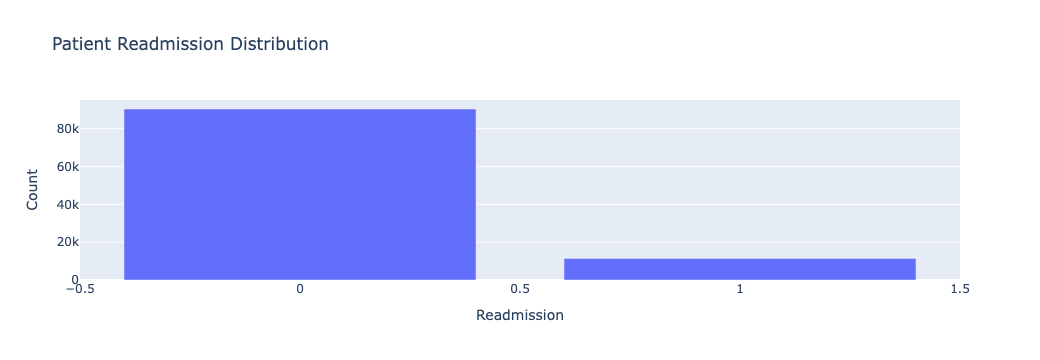

In [26]:
fig = px.bar(df["readmitted"].value_counts().reset_index(),
             x="readmitted",
             y="count",
             title="Patient Readmission Distribution")
fig.update_layout(xaxis_title="Readmission",
                  yaxis_title="Count")
fig.show()

In [27]:
df["age"].value_counts().reset_index().sort_values(by="age")

,age,count
9,[0-10),161
8,[10-20),691
7,[20-30),1657
5,[30-40),3775
4,[40-50),9685
2,[50-60),17256
1,[60-70),22483
0,[70-80),26068
3,[80-90),17197
6,[90-100),2793


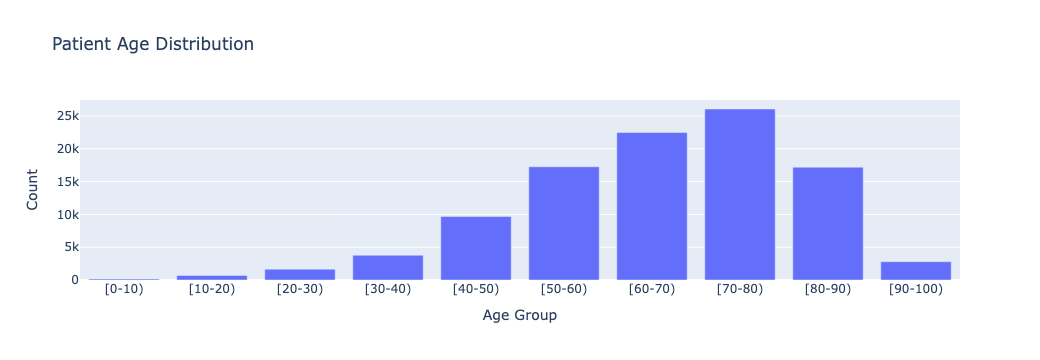

In [28]:

fig = px.bar(df["age"].value_counts().reset_index().sort_values(by="age"), x="age", y="count", title="Patient Age Distribution")
fig.update_layout(xaxis_title="Age Group",
                  yaxis_title="Count")
fig.show()

In [29]:
df['gender'].value_counts()

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

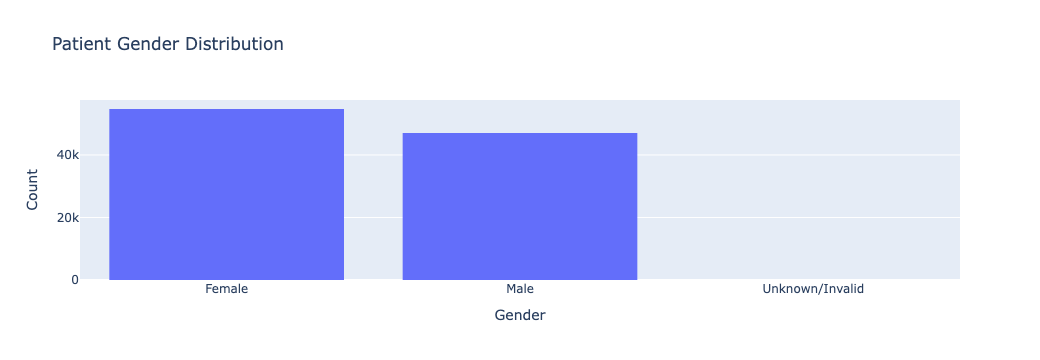

In [30]:
fig = px.histogram(df, x="gender", title="Patient Gender Distribution")
fig.update_layout(xaxis_title="Gender",
                  yaxis_title="Count")
fig.show()

In [31]:
df['admission_type_id'].value_counts()

admission_type_id
1    53990
3    18869
2    18480
6     5291
5     4785
8      320
7       21
4       10
Name: count, dtype: int64

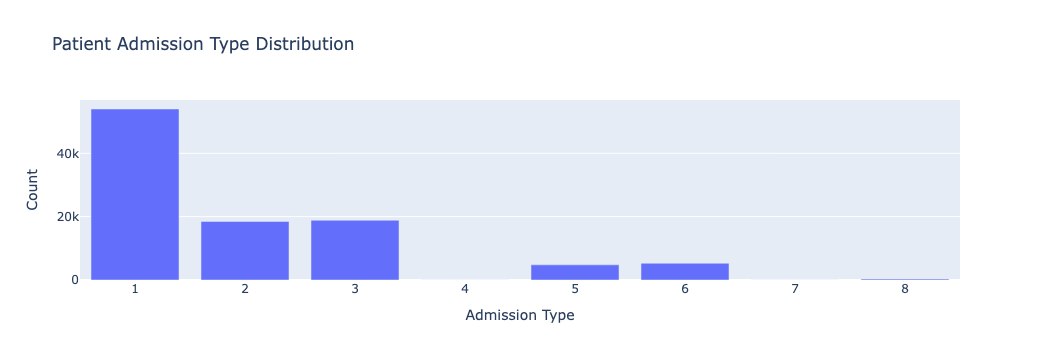

In [32]:
fig = px.bar(df["admission_type_id"].value_counts().reset_index(),
             x="admission_type_id",
             y="count",
             title="Patient Admission Type Distribution")

fig.update_layout(xaxis_title="Admission Type",
                  yaxis_title="Count")

fig.show()

In [35]:
df["max_glu_serum"].value_counts().reset_index().sort_values(by="max_glu_serum")

,max_glu_serum,count
2,>200,1485
3,>300,1264
1,Norm,2597
0,NotMeasured,96420


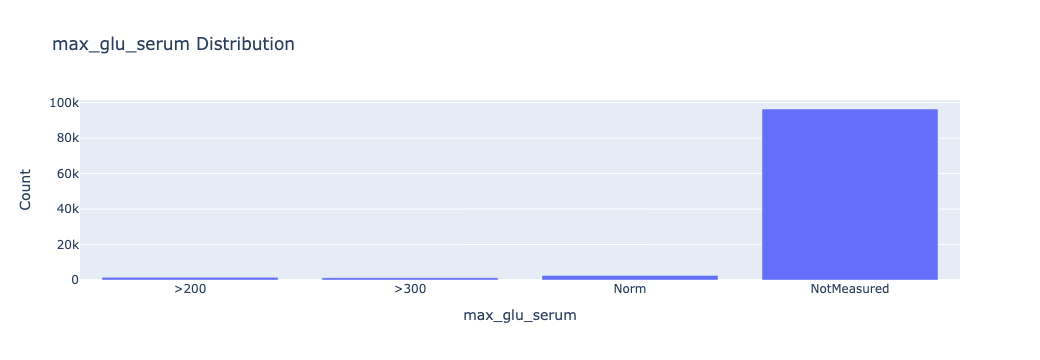

In [36]:

fig = px.bar(df["max_glu_serum"].value_counts().reset_index().sort_values(by="max_glu_serum"), x="max_glu_serum", y="count", title="max_glu_serum Distribution")
fig.update_layout(xaxis_title="max_glu_serum",
                  yaxis_title="Count")
fig.show()

In [37]:
df["A1Cresult"].value_counts().reset_index().sort_values(by="A1Cresult")

,A1Cresult,count
3,>7,3812
1,>8,8216
2,Norm,4990
0,NotMeasured,84748


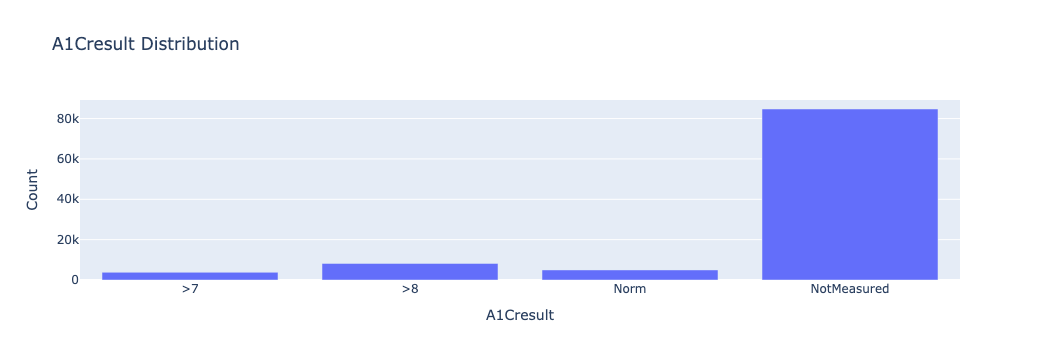

In [38]:
fig = px.bar(df["A1Cresult"].value_counts().reset_index().sort_values(by="A1Cresult"), x="A1Cresult", y="count", title="A1Cresult Distribution")
fig.update_layout(xaxis_title="A1Cresult",
                  yaxis_title="Count")
fig.show()

In [39]:
df["race"].value_counts().reset_index().sort_values(by="race")

,race,count
1,AfricanAmerican,19210
5,Asian,641
0,Caucasian,76099
3,Hispanic,2037
4,Other,1506
2,Unknown,2273


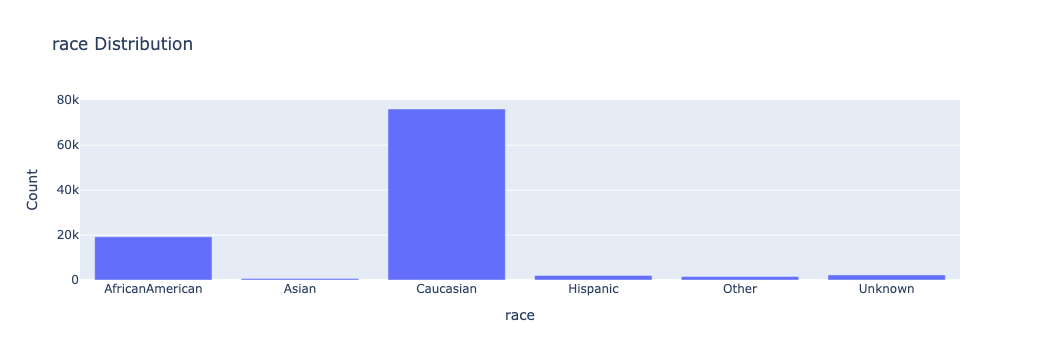

In [40]:
fig = px.bar(df["race"].value_counts().reset_index().sort_values(by="race"), x="race", y="count", title="race Distribution")
fig.update_layout(xaxis_title="race",
                  yaxis_title="Count")
fig.show()

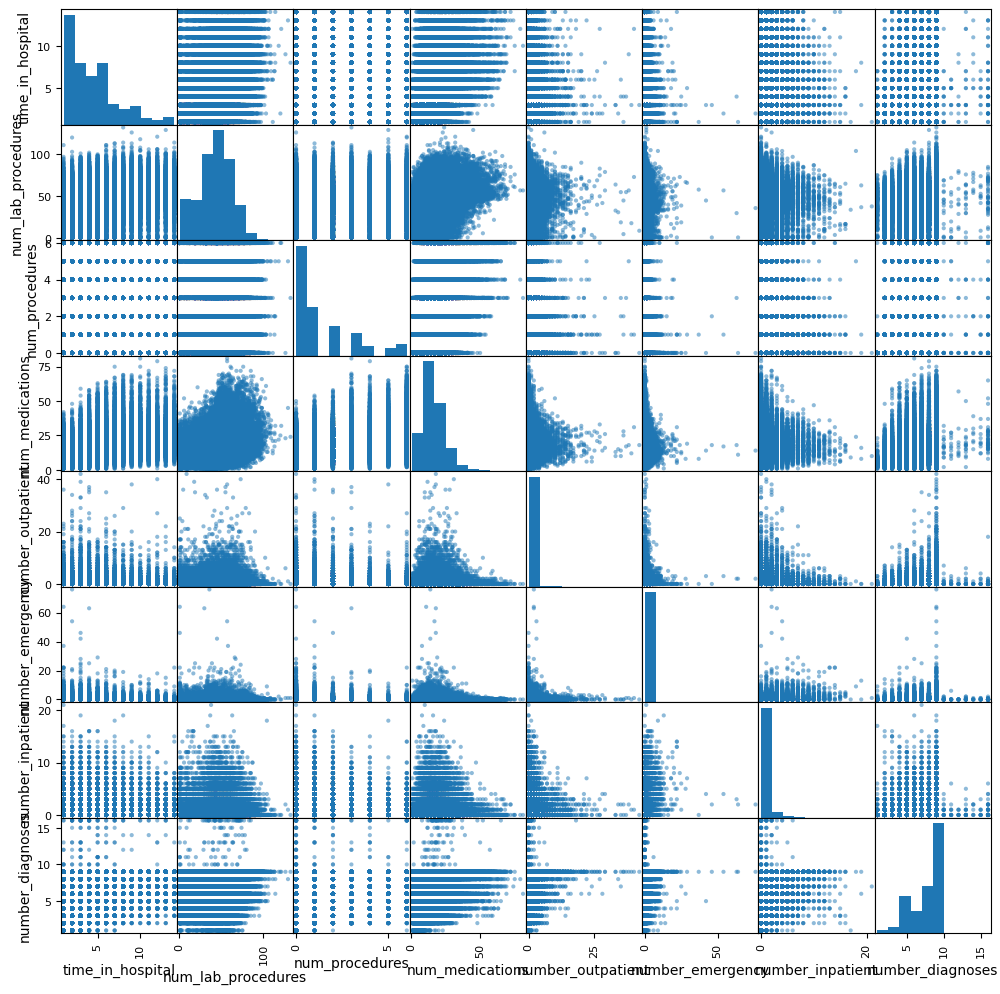

In [41]:
features = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses'
]

scatter_matrix(df[features], figsize=(12, 12))

plt.show()

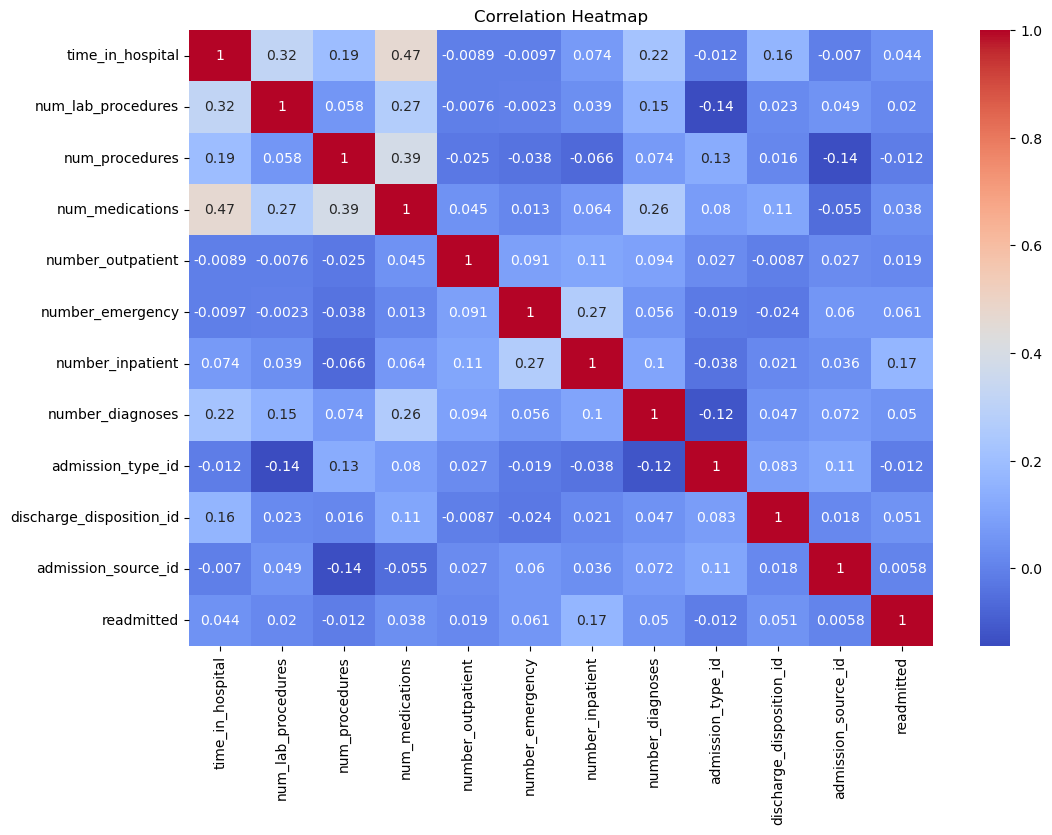

In [42]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12, 8))  
sns.heatmap(corr, annot=True, cmap='coolwarm', )
plt.title("Correlation Heatmap")
plt.show()

In [17]:
X = df.drop("readmitted", axis=1)
y = df["readmitted"]

categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

print("Categorical Columns:", list(categorical_cols))
print("Numerical Columns:", list(numerical_cols))


Categorical Columns: ['gender', 'race', 'age', 'A1Cresult', 'max_glu_serum', 'diabetesMed', 'change', 'insulin', 'metformin', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone']
Numerical Columns: ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id']


In [23]:
X_encoded = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

# Convert all column names to strings
X_encoded.columns = X_encoded.columns.astype(str)

# Remove special characters
X_encoded.columns = (
    X_encoded.columns
    .str.replace('[', '', regex=False)
    .str.replace(']', '', regex=False)
    .str.replace('<', 'lt_', regex=False)
    .str.replace('>', 'gt_', regex=False)
)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(
    X_train[numerical_cols]
)

X_test[numerical_cols] = scaler.transform(
    X_test[numerical_cols]
)

In [46]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000
)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [47]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

In [48]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

print(classification_report(y_test, y_pred))

Accuracy: 0.888375749238479
Precision: 0.4918032786885246
Recall: 0.013210039630118891
F1 Score: 0.025728987993138937
ROC AUC: 0.6441934547466713
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.49      0.01      0.03      2271

    accuracy                           0.89     20354
   macro avg       0.69      0.51      0.48     20354
weighted avg       0.85      0.89      0.84     20354



In [49]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[18052    31]
 [ 2241    30]]


In [50]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

print(feature_importance.head(10))

                     Feature  Coefficient
6           number_inpatient     0.330397
33           diabetesMed_Yes     0.151402
9   discharge_disposition_id     0.128550
29     A1Cresult_NotMeasured     0.112632
7           number_diagnoses     0.079047
34                 change_No     0.067741
13                race_Asian     0.059991
19               age_[20-30)     0.055321
25               age_[80-90)     0.055299
24               age_[70-80)     0.051849


In [25]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:, 1]

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [28]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

                     Accuracy  Precision    Recall  F1 Score   ROC-AUC
Logistic Regression  0.888376   0.491803  0.013210  0.025729  0.644193
Random Forest        0.888671   0.549020  0.012329  0.024117  0.640940
XGBoost              0.888867   0.591837  0.012770  0.025000  0.680871


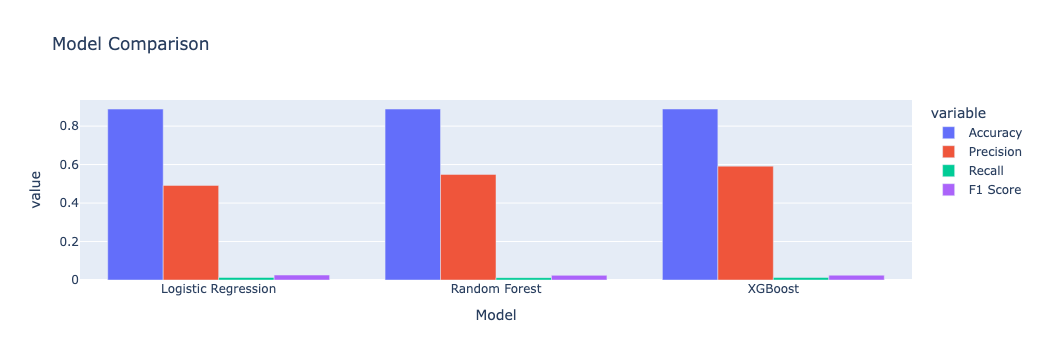

In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }


results = pd.DataFrame({
    "Logistic Regression": evaluate_model(y_test, lr_pred, lr_prob),
    "Random Forest": evaluate_model(y_test, rf_pred, rf_prob),
    "XGBoost": evaluate_model(y_test, xgb_pred, xgb_prob)
}).T

print(results)


import plotly.express as px

results_reset = results.reset_index()
results_reset.rename(columns={"index": "Model"}, inplace=True)

fig = px.bar(
    results_reset,
    x="Model",
    y=["Accuracy", "Precision", "Recall", "F1 Score"],
    barmode="group",
    title="Model Comparison"
)

fig.show()

In [50]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=36)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [51]:
# Logistic Regression

lr_model_smote = LogisticRegression(max_iter=1000)
lr_model_smote.fit(X_train_smote, y_train_smote)

lr_prob_smote = lr_model_smote.predict_proba(X_test)[:, 1]
lr_pred_smote = (lr_prob_smote > 0.25).astype(int)

# Random Forest

rf_model_smote = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model_smote.fit(X_train_smote, y_train_smote)

rf_prob_smote = rf_model_smote.predict_proba(X_test)[:, 1]
rf_pred_smote = (rf_prob_smote > 0.25).astype(int)



# XGBoost

xgb_model_smote = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_model_smote.fit(X_train_smote, y_train_smote)

xgb_prob_smote = xgb_model_smote.predict_proba(X_test)[:, 1]
xgb_pred_smote = (xgb_prob_smote > 0.25).astype(int)

                     Accuracy  Precision    Recall  F1 Score   ROC-AUC
Logistic Regression  0.432888   0.125646  0.685161  0.212351  0.580041
Random Forest        0.772035   0.196981  0.339058  0.249191  0.635420
XGBoost              0.810848   0.228414  0.292382  0.256470  0.654612


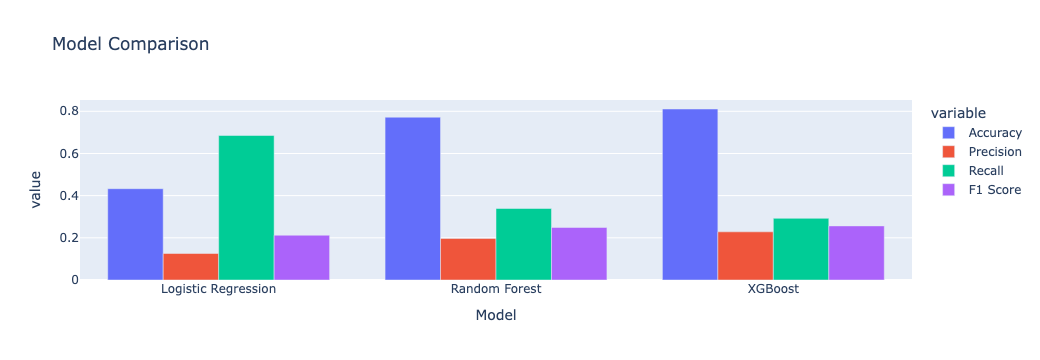

In [52]:
results_smote = pd.DataFrame({
    "Logistic Regression": evaluate_model(y_test, lr_pred_smote, lr_prob_smote),
    "Random Forest": evaluate_model(y_test, rf_pred_smote, rf_prob_smote),
    "XGBoost": evaluate_model(y_test, xgb_pred_smote, xgb_prob_smote)
}).T

print(results_smote)


import plotly.express as px

results_smote_reset = results_smote.reset_index()
results_smote_reset.rename(columns={"index": "Model"}, inplace=True)

fig = px.bar(
    results_smote_reset,
    x="Model",
    y=["Accuracy", "Precision", "Recall", "F1 Score"],
    barmode="group",
    title="Model Comparison"
)

fig.show()